In [ ]:
EXPERIMENT 4

In [ ]:
Scenario 1: Multinomial Naive Bayes - SMS Spam Classification

Classify SMS messages as Spam or Ham (Not Spam) using a probabilistic classification approach.

Dataset :https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset

In [ ]:
Objective:

To implement Multinomial Naive Bayes for text classification and evaluate its performance in detecting spam messages.

In [ ]:
Target Variable: Message Label (Spam / Ham)

Input Feature: SMS Text Message


K.Nivedha(24BAD082)

EXPERIMENT 4

SCENARIO 1: Multinomial Naive Bayes - SMS Spam Classification

Accuracy: 0.967713004484305

Classification Report:

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.76      0.86       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.97      1115



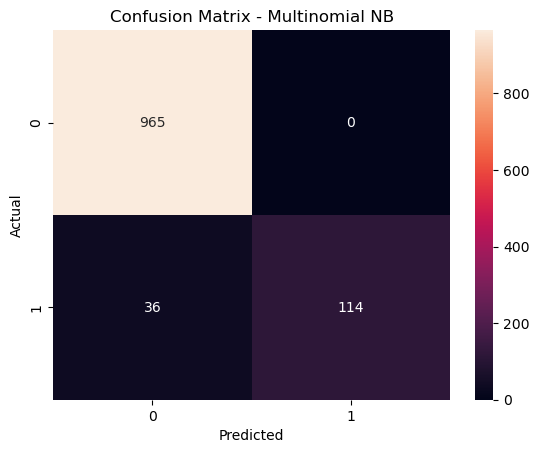

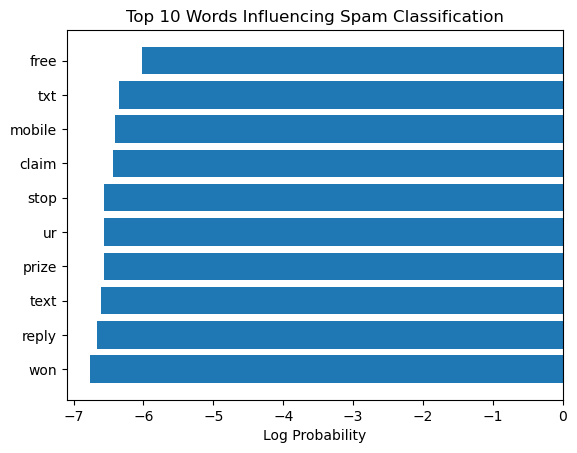

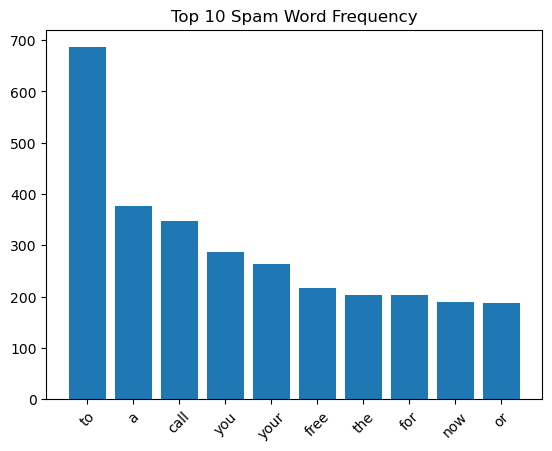

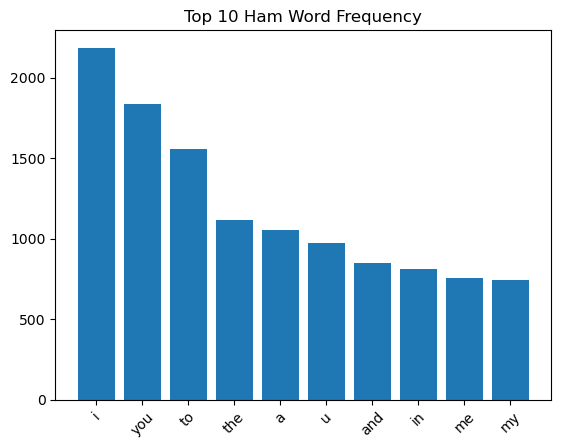

In [1]:
print("\nK.Nivedha(24BAD082)")
print("\nEXPERIMENT 4")
print("\nSCENARIO 1: Multinomial Naive Bayes - SMS Spam Classification\n")

#Import Libraries
import pandas as pd
import numpy as np
import string
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

#Load Dataset 
data = pd.read_csv(r"C:\Users\nived\Downloads\spam.csv", encoding='latin-1')
data = data[['v1', 'v2']]
data.columns = ['label', 'message']

#Text Cleaning
def clean_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

data['message'] = data['message'].apply(clean_text)

#Vectorization (TF-IDF)
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(data['message'])

#Encode Labels
encoder = LabelEncoder()
y = encoder.fit_transform(data['label'])  # ham=0, spam=1

#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Train Model (Laplace smoothing alpha=1)
model = MultinomialNB(alpha=1.0)
model.fit(X_train, y_train)

#Prediction
y_pred = model.predict(X_test)

#Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

#VISUALIZATION 1 – Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Multinomial NB")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#VISUALIZATION 2 – Feature Importance (Top Spam Words)
feature_names = vectorizer.get_feature_names_out()
spam_log_probs = model.feature_log_prob_[1]

top_indices = np.argsort(spam_log_probs)[-10:]
top_words = feature_names[top_indices]
top_values = spam_log_probs[top_indices]

plt.figure()
plt.barh(top_words, top_values)
plt.title("Top 10 Words Influencing Spam Classification")
plt.xlabel("Log Probability")
plt.show()

# VISUALIZATION 3 – Word Frequency Comparison
spam_messages = data[data['label'] == 'spam']['message']
ham_messages = data[data['label'] == 'ham']['message']

spam_words = " ".join(spam_messages).split()
ham_words = " ".join(ham_messages).split()

spam_counter = Counter(spam_words)
ham_counter = Counter(ham_words)

top_spam = dict(spam_counter.most_common(10))
top_ham = dict(ham_counter.most_common(10))

plt.figure()
plt.bar(top_spam.keys(), top_spam.values())
plt.xticks(rotation=45)
plt.title("Top 10 Spam Word Frequency")
plt.show()

plt.figure()
plt.bar(top_ham.keys(), top_ham.values())
plt.xticks(rotation=45)
plt.title("Top 10 Ham Word Frequency")
plt.show()








In [ ]:
Steps Performed:

1.Imported required Python libraries
2.Loaded SMS spam dataset
3.Performed text preprocessing:
    -Lowercase conversion
    -Punctuation removal
    -Stopword removal
4.Converted text into numerical format using TF-IDF
5.Encoded target labels
6.Split dataset into training and testing sets
7.Trained Multinomial Naive Bayes classifier
8.Predicted message classes
9.Evaluated model using:
    -Accuracy
    -Precision
    -Recall
    -F1 Score
10.Visualized:
    -Confusion Matrix
    -Top spam words
    -Word frequency comparison

In [ ]:
Output:

The model successfully classified SMS messages as Spam or Ham.
Achieved high classification accuracy.
Confusion matrix showed minimal false positives and false negatives.
Important spam-indicating words were identified.
Laplace smoothing prevented zero probability issues.

In [ ]:
Scenario 2: Gaussian Naive Bayes - Iris Classification

Classify flower species based on physical measurements using a probabilistic classifier.

Dataset: Iris Dataset (Built-in sklearn dataset)

In [ ]:
Objective:

To implement Gaussian Naive Bayes for numerical classification and analyze class probabilities.

In [ ]:
Target Variable: Flower Species

Input Features: Sepal Length, Sepal Width, Petal Length, Petal Width


K.Nivedha(24BAD082)

EXPERIMENT 4

SCENARIO 2: Gaussian Naive Bayes - Iris Classification

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



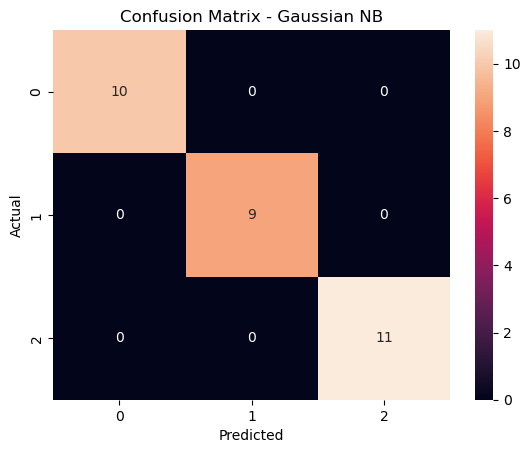

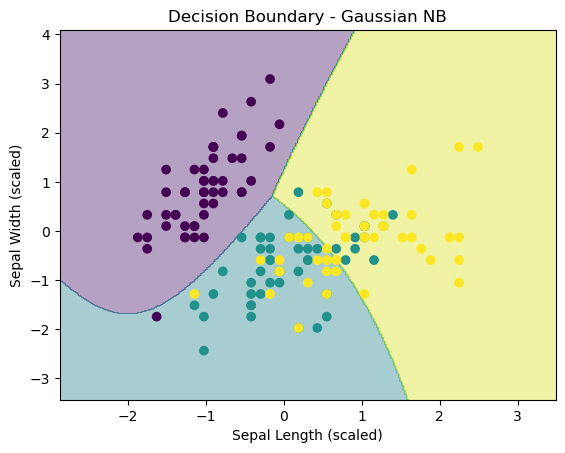

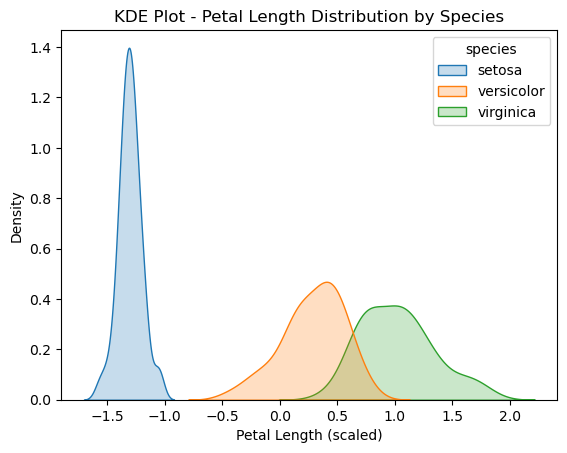

In [2]:
print("\nK.Nivedha(24BAD082)")
print("\nEXPERIMENT 4")
print("\nSCENARIO 2: Gaussian Naive Bayes - Iris Classification\n")

#Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#Load Iris Dataset
iris = load_iris()
X = iris.data
y = iris.target

#Convert to DataFrame for visualization
df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = y

#Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

#Train Gaussian Naïve Bayes
gnb = GaussianNB()
gnb.fit(X_train, y_train)

#Prediction
y_pred = gnb.predict(X_test)

#Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

#VISUALIZATION 1 – Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Gaussian NB")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#VISUALIZATION 2 – Decision Boundary (First 2 Features)
X2 = X_scaled[:, :2]

model2 = GaussianNB()
model2.fit(X2, y)

x_min, x_max = X2[:, 0].min() - 1, X2[:, 0].max() + 1
y_min, y_max = X2[:, 1].min() - 1, X2[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

Z = model2.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, Z, alpha=0.4)
plt.scatter(X2[:, 0], X2[:, 1], c=y)
plt.xlabel("Sepal Length (scaled)")
plt.ylabel("Sepal Width (scaled)")
plt.title("Decision Boundary - Gaussian NB")
plt.show()

# VISUALIZATION 3 – Petal Length Distribution

# Use scaled data for KDE
df_scaled = pd.DataFrame(X_scaled, columns=iris.feature_names)
df_scaled['species'] = y
df_scaled['species'] = df_scaled['species'].map({
    0: iris.target_names[0],
    1: iris.target_names[1],
    2: iris.target_names[2]
})

plt.figure()
sns.kdeplot(data=df_scaled,
            x='petal length (cm)',
            hue='species',
            fill=True)

plt.title("KDE Plot - Petal Length Distribution by Species")
plt.xlabel("Petal Length (scaled)")
plt.ylabel("Density")
plt.show()


In [ ]:
Steps Performed:

1.Imported required libraries
2.Loaded Iris dataset
3.Inspected dataset and converted to DataFrame
4.Applied feature scaling using StandardScaler
5.Split dataset into training and testing sets
6.Trained Gaussian Naive Bayes classifier
7.Predicted species labels
8.Evaluated model using:
    -Accuracy
    -Precision
    -Recall
    -F1 Score
9.Visualized:
    -Confusion Matrix
    -Decision Boundary Plot
    -KDE Distribution Plot

In [ ]:
Output:

The Gaussian Naïve Bayes model accurately classified flower species.
High prediction accuracy was achieved.
Decision boundary plot clearly showed separation between classes.
Class probability analysis helped understand model confidence.
Feature scaling improved prediction stability.